In [1]:
getwd()
setwd("/liulab/galib/dlbcl_manuscript/")
library(rBCS)
library(tidyverse)
library(Seurat)
library(harmony)
library(viridis)
library(RColorBrewer)
library(Polychrome)
PurpleAndYellow()
library(ComplexHeatmap)
library(devtools)
library(presto)
library(dplyr)
library(ggplot2)
library(ggpubr)
library(readxl)
library(DESeq2)
set.seed(123)
source("./scripts/scplot.R")

[1] "/liulab/galib/dlbcl_manuscript/scripts/Revision"

Warning message:
“package ‘rBCS’ was built under R version 4.1.3”
Warning message:
“package ‘tidyverse’ was built under R version 4.1.3”
── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──

✔ ggplot2 3.3.6      ✔ purrr   0.3.4 
✔ tibble  3.1.8      ✔ dplyr   1.0.10
✔ tidyr   1.2.0      ✔ stringr 1.4.1 
✔ readr   2.1.2      ✔ forcats 0.5.1 

Warning message:
“package ‘tidyr’ was built under R version 4.1.2”
Warning message:
“package ‘readr’ was built under R version 4.1.2”
Warning message:
“package ‘forcats’ was built under R version 4.1.3”
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()

Attaching SeuratObject

Attaching sp

Warning message:
“package ‘harmony’ was built under R version 4.1.3”
Loading required package: Rcpp

Warning message:
“package ‘Rcpp’ was built under R version 4.1.2”
Loading required package: viridisLite

Warning message:
“pack

[1] "#FF00FF" "#F400F4" "#EA00EA" "#DF00DF" "#D500D5" "#CA00CA" "#BF00BF"
 [8] "#B500B5" "#AA00AA" "#9F009F" "#950095" "#8A008A" "#800080" "#750075"
[15] "#6A006A" "#600060" "#550055" "#4A004A" "#400040" "#350035" "#2B002B"
[22] "#200020" "#150015" "#0B000B" "#000000" "#000000" "#0B0B00" "#151500"
[29] "#202000" "#2B2B00" "#353500" "#404000" "#4A4A00" "#555500" "#606000"
[36] "#6A6A00" "#757500" "#808000" "#8A8A00" "#959500" "#9F9F00" "#AAAA00"
[43] "#B5B500" "#BFBF00" "#CACA00" "#D4D400" "#DFDF00" "#EAEA00" "#F4F400"
[50] "#FFFF00"

Warning message:
“package ‘ComplexHeatmap’ was built under R version 4.1.3”
Loading required package: grid

ComplexHeatmap version 2.10.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite:
Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
  genomic data. Bioinformatics 2016.

The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


Loading required package: usethis

Warning message:
“package ‘presto’ was built under R version 4.1.3”
Loading required package: data.table


Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


The

In [5]:
inpath = "./data/revision/pseudobulk_de/deseq2/"

6mos

14mos

18mos

sick

all_timepoints



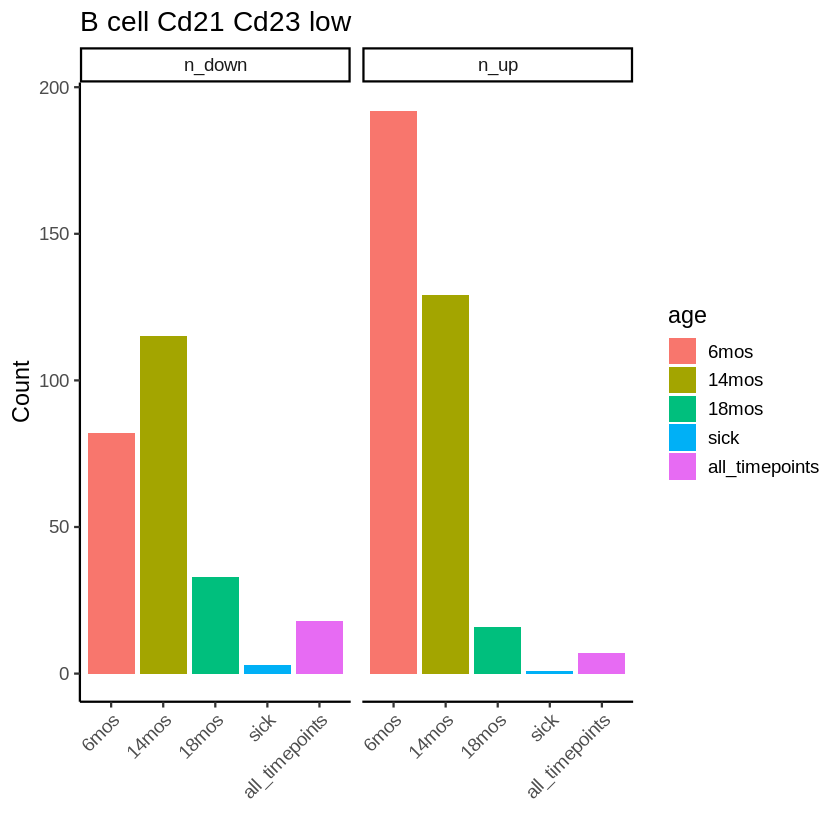

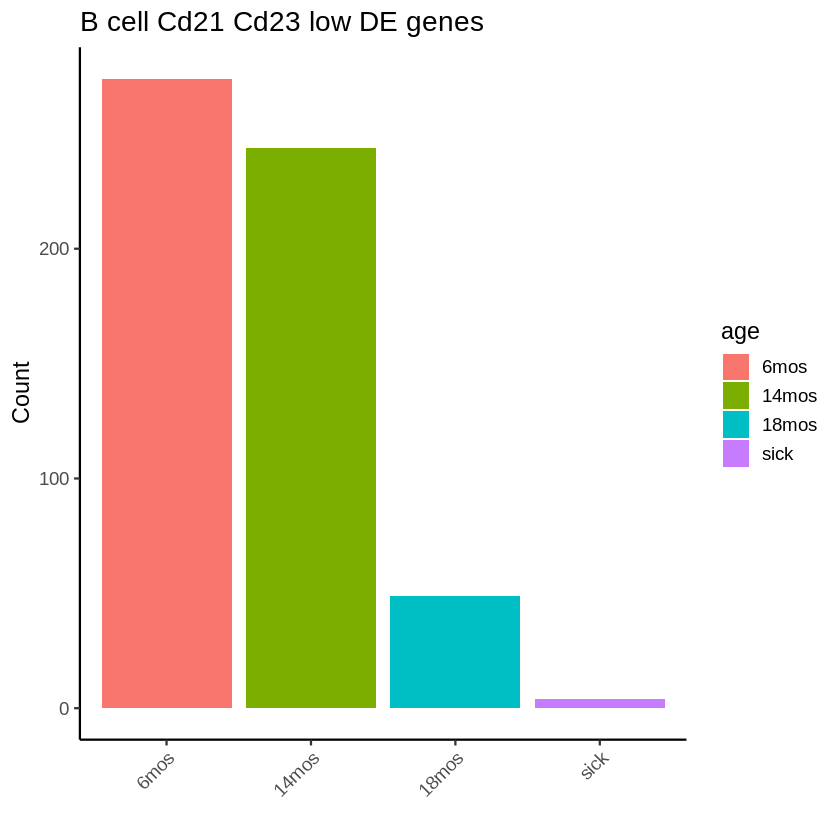

In [72]:
n_ups = c()
n_downs = c()
ages = c()

for (age in c("6mos", "14mos", "18mos", "sick", "all_timepoints")){
    
    message(age)
    ages = c(ages, age)
    file = paste0("b_cell_cd21_cd23_low_de_", age, "_significant_markers_padj_0.05_abslogFC_1.0.tsv")
    
    de_df<- read.table(paste0(inpath, file), sep = "\t", header = T)
    n_up = de_df  %>% filter(sig == "Up")  %>% nrow()
    n_ups = c(n_ups, n_up)
    n_down = de_df  %>% filter(sig == "Down")  %>% nrow()
    n_downs = c(n_downs, n_down)
    
}


df<- data.frame("age" = ages, "n_up" = n_ups, "n_down" = n_downs)  %>% 
    pivot_longer(cols = c(n_up, n_down), names_to = "direction", values_to = "n")


df$direction<- factor(df$direction, levels = c("n_down", "n_up"))
df$age<- factor(df$age, levels = c('6mos', '14mos', '18mos', 'sick', 'all_timepoints'))


df  %>%
    ggplot(aes(x = age, y = n, fill = age))  +
    geom_bar(stat = "identity")  +
    facet_wrap(facets = "direction") +
    theme_classic(base_size = 14) +
    labs(x = "", y = "Count", title = "B cell Cd21 Cd23 low") +
     theme(axis.text.x = element_text(angle = 45, hjust = 1))

ggsave('./data/revision/pseudobulk_de/deseq2/B_cell_cd21_cd23_low_number_of_up_down_regulated_genes.pdf', 
       width = 6, height = 4)

df  %>%
    filter(age != "all_timepoints")  %>% 
    group_by(age)  %>% 
    summarise(total_de = sum(n))  %>% 
    ggplot(aes(x = age, y = total_de, fill = age))  +
    geom_bar(stat = "identity")  +
    theme_classic(base_size = 14) +
    labs(x = "", y = "Count", title = "B cell Cd21 Cd23 low DE genes") +
     theme(axis.text.x = element_text(angle = 45, hjust = 1))

ggsave('./data/revision/pseudobulk_de/deseq2/B_cell_cd21_cd23_low_number_of_de_genes.pdf', 
       width = 6, height = 4)

6mos

14mos

18mos

sick

all_timepoints



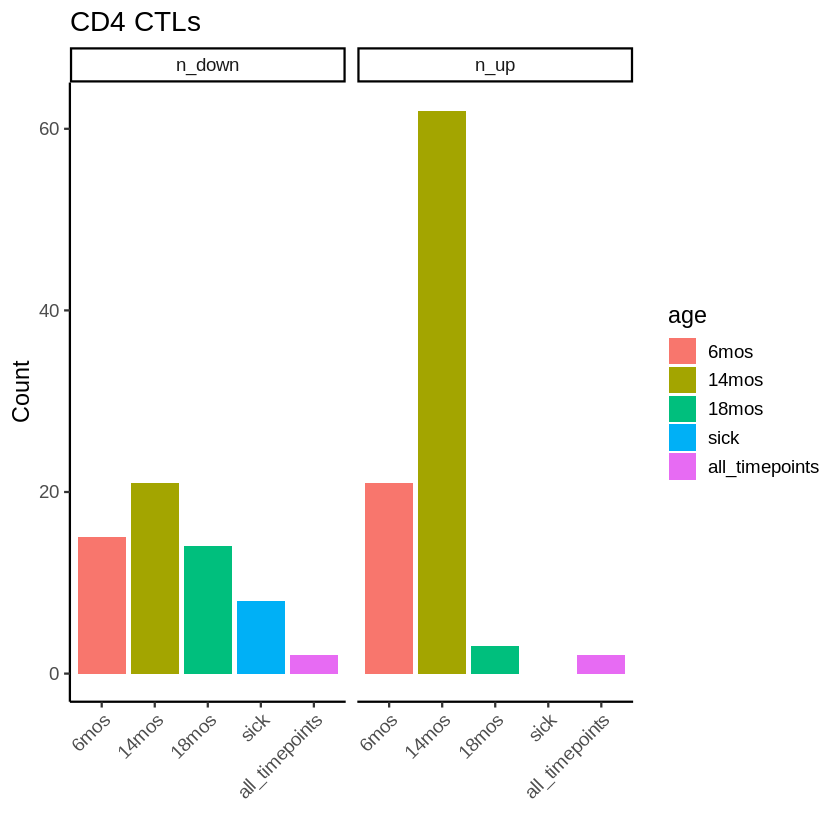

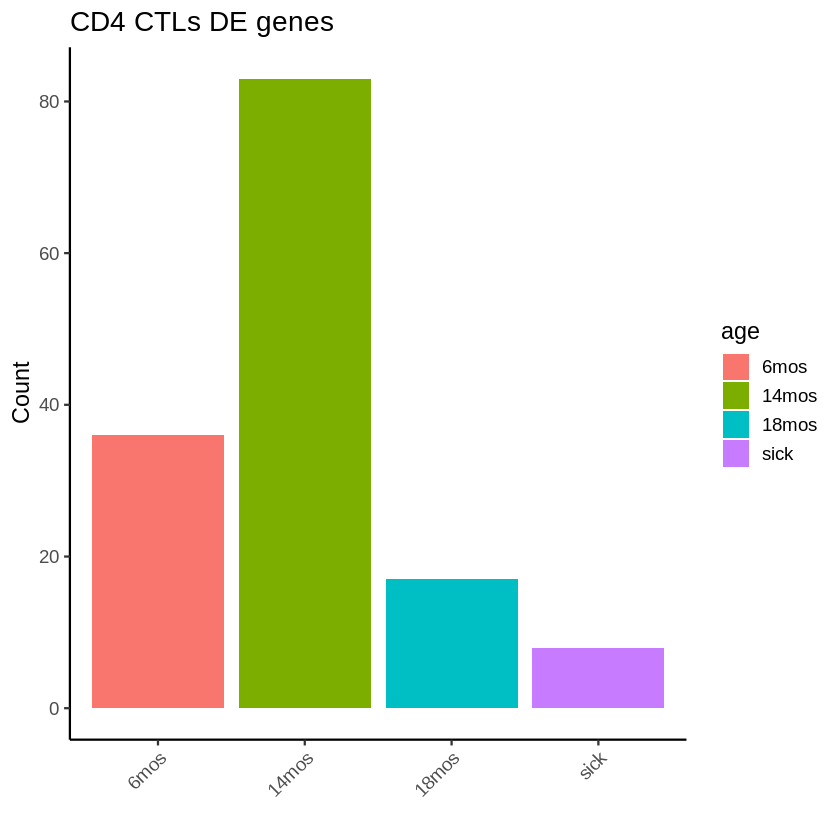

In [73]:
n_ups = c()
n_downs = c()
ages = c()

for (age in c("6mos", "14mos", "18mos", "sick", "all_timepoints")){
    
    message(age)
    ages = c(ages, age)
    file = paste0("cd4_ctl_de_", age, "_significant_markers_padj_0.05_abslogFC_1.0.tsv")
    
    de_df<- read.table(paste0(inpath, file), sep = "\t", header = T)
    n_up = de_df  %>% filter(sig == "Up")  %>% nrow()
    n_ups = c(n_ups, n_up)
    n_down = de_df  %>% filter(sig == "Down")  %>% nrow()
    n_downs = c(n_downs, n_down)
    
}


df<- data.frame("age" = ages, "n_up" = n_ups, "n_down" = n_downs)  %>% 
    pivot_longer(cols = c(n_up, n_down), names_to = "direction", values_to = "n")


df$direction<- factor(df$direction, levels = c("n_down", "n_up"))
df$age<- factor(df$age, levels = c('6mos', '14mos', '18mos', 'sick', 'all_timepoints'))



df  %>% 
    ggplot(aes(x = age, y = n, fill = age))  +
    geom_bar(stat = "identity")  +
    facet_wrap(facets = "direction") +
    theme_classic(base_size = 14) +
    labs(x = "", y = "Count", title = "CD4 CTLs") +
     theme(axis.text.x = element_text(angle = 45, hjust = 1))

ggsave('./data/revision/pseudobulk_de/deseq2/Cd4_CTLs_number_of_up_down_regulated_genes.pdf', 
       width = 6, height = 4)


df  %>%
    filter(age != "all_timepoints")  %>% 
    group_by(age)  %>% 
    summarise(total_de = sum(n))  %>% 
    ggplot(aes(x = age, y = total_de, fill = age))  +
    geom_bar(stat = "identity")  +
    theme_classic(base_size = 14) +
    labs(x = "", y = "Count", title = "CD4 CTLs DE genes") +
     theme(axis.text.x = element_text(angle = 45, hjust = 1))

ggsave('./data/revision/pseudobulk_de/deseq2/Cd4_CTLs_number_of_de_genes.pdf', 
       width = 6, height = 4)

In [2]:
library(clusterProfiler)
library("org.Mm.eg.db")



Registered S3 method overwritten by 'ggtree':
  method      from 
  identify.gg ggfun

clusterProfiler v4.2.2  For help: https://yulab-smu.top/biomedical-knowledge-mining-book/

If you use clusterProfiler in published research, please cite:
T Wu, E Hu, S Xu, M Chen, P Guo, Z Dai, T Feng, L Zhou, W Tang, L Zhan, X Fu, S Liu, X Bo, and G Yu. clusterProfiler 4.0: A universal enrichment tool for interpreting omics data. The Innovation. 2021, 2(3):100141


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:IRanges’:

    slice


The following object is masked from ‘package:S4Vectors’:

    rename


The following object is masked from ‘package:purrr’:

    simplify


The following object is masked from ‘package:stats’:

    filter


Warning message:
“package ‘org.Mm.eg.db’ was built under R version 4.1.3”
Loading required package: AnnotationDbi


Attaching package: ‘AnnotationDbi’


The following object is masked from ‘package:clusterProfiler’:

    select


In [66]:
runEnrichGO<- function(prefix, genelist, age, dir){
    
    ego_CC <- enrichGO(gene   = genelist,
                OrgDb         = org.Mm.eg.db,
                keyType       = 'SYMBOL',
                ont           = "CC",
                pAdjustMethod = "BH",
                pvalueCutoff  = 0.01,
                qvalueCutoff  = 0.05)

    ego_MF <- enrichGO(gene       = genelist,
                    OrgDb         = org.Mm.eg.db,
                    keyType       = 'SYMBOL',
                    ont           = "MF",
                    pAdjustMethod = "BH",
                    pvalueCutoff  = 0.01,
                    qvalueCutoff  = 0.05)
    
    ego_BP <- enrichGO(gene       = genelist,
                    OrgDb         = org.Mm.eg.db,
                    keyType       = 'SYMBOL',
                    ont           = "BP",
                    pAdjustMethod = "BH",
                    pvalueCutoff  = 0.01,
                    qvalueCutoff  = 0.05)
    
    p_enrich_cc = EnrichedView(ego_CC, top = 10, bottom = 10, mode = 1)
    p_enrich_cc
    p_enrich_mf = EnrichedView(ego_MF, top = 10, bottom = 10, mode = 1)
    p_enrich_mf
    p_enrich_bp = EnrichedView(ego_BP, top = 10, bottom = 10, mode = 1)
    p_enrich_bp
    
    p_enrich_cc = p_enrich_cc + labs(title = 'GO CC over-representation analysis')
    ggsave(filename = paste0("./data/revision/pseudobulk_de/deseq2/pathway_enrich/260317_", prefix, "_", age, "_", dir, "_gene_GO_CC_enrich.pdf"), plot = p_enrich_cc, width = 6, height = 5)
    p_enrich_mf = p_enrich_mf + labs(title = 'GO MF over-representation analysis')
    ggsave(filename = paste0("./data/revision/pseudobulk_de/deseq2/pathway_enrich/260317_", prefix, "_", age, "_", dir, "_gene_GO_MF_enrich.pdf"), plot = p_enrich_mf, width = 6, height = 5)
    p_enrich_bp = p_enrich_bp + labs(title = 'GO BP over-representation analysis')
    ggsave(filename = paste0("./data/revision/pseudobulk_de/deseq2/pathway_enrich/260317_", prefix, "_", age, "_", dir, "_gene_GO_BP_enrich.pdf"), plot = p_enrich_bp, width = 6, height = 5)
}

In [67]:
n_ups = c()
n_downs = c()
ages = c()

for (age in c("6mos", "14mos", "18mos", "sick", "all_timepoints")){
    
    message(age)
    ages = c(ages, age)
    file = paste0("b_cell_cd21_cd23_low_de_", age, "_significant_markers_padj_0.05_abslogFC_1.0.tsv")
    prefix = "B_cell_Cd21_Cd23_low"
    de_df<- read.table(paste0(inpath, file), sep = "\t", header = T)
    
    gene_up = de_df  %>% filter(sig == "Up")  %>% pull(feature)
    runEnrichGO(prefix = prefix, genelist = gene_up, age = age, dir = "up_regulated")
    
    gene_down = de_df  %>% filter(sig == "Down")  %>% pull(feature)
    runEnrichGO(prefix = prefix, genelist = gene_down, age = age, dir = "down_regulated")

}

6mos

14mos

18mos

sick

No gene sets have size between 10 and 500 ...

--> return NULL...

--> No gene can be mapped....

--> Expected input gene ID: Alg1,Rbbp8,Exog,Pdss1,Dpy19l4,Alg8

--> return NULL...

all_timepoints



In [74]:
n_ups = c()
n_downs = c()
ages = c()

for (age in c("6mos", "14mos", "18mos", "sick", "all_timepoints")){
    
    message(age)
    ages = c(ages, age)
    file = paste0("cd4_ctl_de_", age, "_significant_markers_padj_0.05_abslogFC_1.0.tsv")
    prefix = "CD4_CTLs"
    de_df<- read.table(paste0(inpath, file), sep = "\t", header = T)
    
    gene_up = de_df  %>% filter(sig == "Up")  %>% pull(feature)
    runEnrichGO(prefix = prefix, genelist = gene_up, age = age, dir = "up_regulated")
    
    gene_down = de_df  %>% filter(sig == "Down")  %>% pull(feature)
    runEnrichGO(prefix = prefix, genelist = gene_down, age = age, dir = "down_regulated")

}

6mos

14mos

18mos

sick

--> No gene can be mapped....

--> Expected input gene ID: Cetn2,Ing4,Zzz3,Phf12,Nrip1,Atxn7l3

--> return NULL...

--> No gene can be mapped....

--> Expected input gene ID: Ggt5,Tmtc4,Pomt1,Rad50,Alg9,Pigv

--> return NULL...

--> No gene can be mapped....

--> Expected input gene ID: Fscn3,Primpol,Prl7a2,Ccdc42,Mlh1,Rrs1

--> return NULL...

all_timepoints



In [ ]:
library(createKEGGdb)
species <-c("hsa","mmu")
createKEGGdb::create_kegg_db(species)
# setwd()
# install.packages("KEGG.db_1.0.tar.gz", repos=NULL,type="source")
library(KEGG.db)

keggpathid2name.df <- clusterProfiler:::kegg_list("pathway/mmu")

In [54]:
runEnrichKEGG <- function(prefix, genelist, age, dir){

    gene_entrez = bitr(genelist, fromType="SYMBOL", toType="ENTREZID", OrgDb="org.Mm.eg.db")

    gene_entrez_clean <- gene_entrez %>% 
        filter(!is.na(ENTREZID)) %>%
        pull(ENTREZID) %>%
        as.character()

    kk <- enrichKEGG(gene = gene_entrez_clean,
                     organism     = 'mmu',
                     pvalueCutoff = 0.05,
                     pAdjustMethod = "BH", use_internal_data=T)
    kk@result$Description<-strsplit(keggpathid2name.df$to[match(kk@result$ID,keggpathid2name.df$from)],
                                      split = " - Mus musculus (house mouse)", fixed = T)
    
    p_enrich_kk = EnrichedView(kk, top = 10, bottom = 10, mode = 1)
    p_enrich_kk = p_enrich_kk + labs(title = 'KEGG over-representation analysis')
    
    ggsave(filename = paste0("./data/revision/pseudobulk_de/deseq2/pathway_enrich/260318_", prefix, "_", age, "_", dir, "_gene_KEGG_enrich.pdf"), plot = p_enrich_kk, width = 6, height = 5)

}

In [55]:
n_ups = c()
n_downs = c()
ages = c()

for (age in c("6mos", "14mos", "18mos")){
    
    message(age)
    ages = c(ages, age)
    file = paste0("b_cell_cd21_cd23_low_de_", age, "_significant_markers_padj_0.05_abslogFC_1.0.tsv")
    prefix = "B_cell_Cd21_Cd23_low"
    de_df<- read.table(paste0(inpath, file), sep = "\t", header = T)
    
    gene_up = de_df  %>% filter(sig == "Up")  %>% pull(feature)
    runEnrichKEGG(prefix = prefix, genelist = gene_up, age = age, dir = "up_regulated")
    
    gene_down = de_df  %>% filter(sig == "Down")  %>% pull(feature)
    runEnrichKEGG(prefix = prefix, genelist = gene_down, age = age, dir = "down_regulated")

}

6mos

'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(genelist, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = "org.Mm.eg.db"):
“6.77% of input gene IDs are fail to map...”
'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(genelist, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = "org.Mm.eg.db"):
“7.32% of input gene IDs are fail to map...”
14mos

'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(genelist, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = "org.Mm.eg.db"):
“6.98% of input gene IDs are fail to map...”
'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(genelist, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = "org.Mm.eg.db"):
“9.57% of input gene IDs are fail to map...”
18mos

'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(genelist, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = "org.Mm.eg.db"):
“6.25

In [56]:
n_ups = c()
n_downs = c()
ages = c()

for (age in c("6mos", "14mos", "18mos")){
    
    message(age)
    ages = c(ages, age)
    file = paste0("cd4_ctl_de_", age, "_significant_markers_padj_0.05_abslogFC_1.0.tsv")
    prefix = "CD4_CTLs"
    de_df<- read.table(paste0(inpath, file), sep = "\t", header = T)
    
    gene_up = de_df  %>% filter(sig == "Up")  %>% pull(feature)
    runEnrichKEGG(prefix = prefix, genelist = gene_up, age = age, dir = "up_regulated")
    
    gene_down = de_df  %>% filter(sig == "Down")  %>% pull(feature)
    runEnrichKEGG(prefix = prefix, genelist = gene_down, age = age, dir = "down_regulated")


}

6mos

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

14mos

'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(genelist, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = "org.Mm.eg.db"):
“4.84% of input gene IDs are fail to map...”
'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(genelist, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = "org.Mm.eg.db"):
“9.52% of input gene IDs are fail to map...”
18mos

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(genelist, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = "org.Mm.eg.db"):
“7.14% of input gene IDs are fail to map...”
